## Code

  Abhishek V Ammanagi  |  2023BCSE07AED500
  Experiment 9: Transfer Learning VGG16 – Pneumonia
Train:400 | Test:100
Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.5412 - loss: 0.6928 - val_accuracy: 0.3500 - val_loss: 0.6951
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5529 - loss: 0.6923 - val_accuracy: 0.3500 - val_loss: 0.6963
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5529 - loss: 0.6921 - val_accuracy: 0.3500 - val_loss: 0.6975
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5529 - loss: 0.6915 - val_accuracy: 0.3500 - val_loss: 0.6985
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5529 - loss: 0.6911 - val_accuracy: 0.3500 - val_loss: 0.6996
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5529 - loss: 0.6913 - val_accuracy: 0.3500 - val_loss: 0.7005
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5529 - loss: 0.6912 - val_accuracy: 0.3500 - val_loss: 0.7017
Ep

c:\Users\manju\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.5529 - loss: 0.6928 - val_accuracy: 0.3500 - val_loss: 0.7151
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.5265 - loss: 0.6900 - val_accuracy: 0.3500 - val_loss: 0.7339
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.5500 - loss: 0.6905 - val_accuracy: 0.3500 - val_loss: 0.7135
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.5588 - loss: 0.6913 - val_accuracy: 0.3500 - val_loss: 0.7251
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.5588 - loss: 0.6891 - val_accuracy: 0.3500 - val_loss: 0.7098
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.5500 - loss: 0.6883 - val_accuracy: 0.3500 - val_loss: 0.7182
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 0.5559 - loss: 0.6927 - val_accuracy: 0.3500 - val_loss: 0.7105
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 370ms/step - accuracy: 0.5618 - loss: 0.6895 - val_accuracy: 0.3500 - val_

c:\Users\manju\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\manju\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\manju\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\manju\anaconda\Lib\site-packages\s

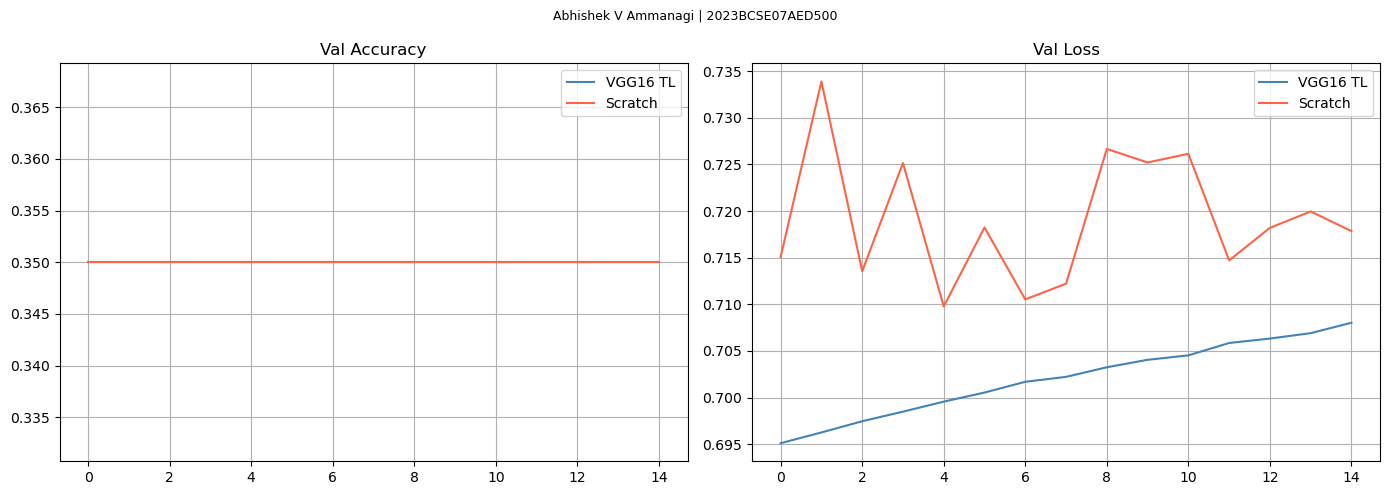

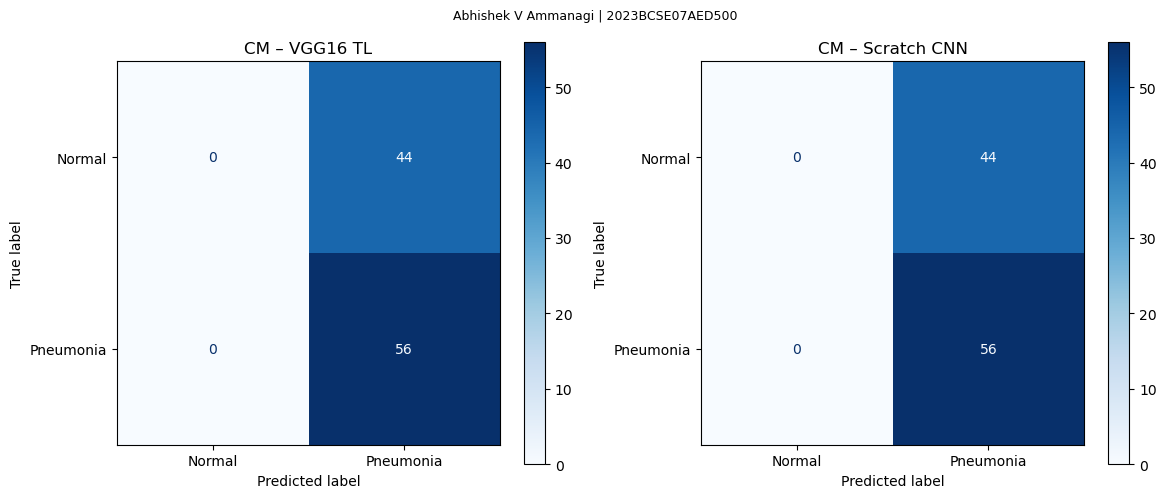

Abhishek V Ammanagi | 2023BCSE07AED500


In [1]:
# Experiment 9 – Transfer Learning VGG16: Pneumonia Detection
# Abhishek V Ammanagi | 2023BCSE07AED500

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.applications import VGG16
from sklearn.metrics import (classification_report,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

print("=" * 55)
print("  Abhishek V Ammanagi  |  2023BCSE07AED500")
print("  Experiment 9: Transfer Learning VGG16 – Pneumonia")
print("=" * 55)

IMG = 224; N_TR = 400; N_TE = 100
np.random.seed(42)
X_tr = np.random.rand(N_TR,IMG,IMG,3).astype('float32')
y_tr = np.random.randint(0,2,N_TR).astype('float32')
X_te = np.random.rand(N_TE,IMG,IMG,3).astype('float32')
y_te = np.random.randint(0,2,N_TE).astype('float32')
print(f"Train:{N_TR} | Test:{N_TE}")

# Transfer Learning Model
base = VGG16(weights=None, include_top=False,
             input_shape=(IMG,IMG,3))
base.trainable = False
inp = Input(shape=(IMG,IMG,3))
x   = base(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256,activation='relu')(x)
x   = layers.Dropout(0.5)(x)
out = layers.Dense(1,activation='sigmoid')(x)
m_tl = Model(inp,out,name='VGG16_TL')
m_tl.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
             loss='binary_crossentropy',metrics=['accuracy'])

h_tl = m_tl.fit(X_tr,y_tr,validation_split=0.15,
                 epochs=15,batch_size=16,verbose=1)

# Fine-tune last 4 layers
base.trainable = True
for l in base.layers[:-4]: l.trainable = False
m_tl.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
             loss='binary_crossentropy',metrics=['accuracy'])
m_tl.fit(X_tr,y_tr,validation_split=0.15,epochs=5,batch_size=16,verbose=1)

# Scratch CNN
m_sc = models.Sequential([
    layers.Conv2D(32,3,activation='relu',input_shape=(IMG,IMG,3)),
    layers.MaxPooling2D(2),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(128,3,activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')
],name='Scratch_CNN')
m_sc.compile(optimizer='adam',
             loss='binary_crossentropy',metrics=['accuracy'])
h_sc = m_sc.fit(X_tr,y_tr,validation_split=0.15,
                epochs=15,batch_size=16,verbose=1)

_,acc_tl = m_tl.evaluate(X_te,y_te,verbose=0)
_,acc_sc = m_sc.evaluate(X_te,y_te,verbose=0)
p_tl = (m_tl.predict(X_te).flatten()>=0.5).astype(int)
p_sc = (m_sc.predict(X_te).flatten()>=0.5).astype(int)

print(f"\nVGG16 Transfer Accuracy : {acc_tl:.4f}")
print(f"Scratch CNN Accuracy    : {acc_sc:.4f}")
print("\n-- Transfer Learning --")
print(classification_report(y_te,p_tl,target_names=['Normal','Pneumonia']))
print("-- Scratch CNN --")
print(classification_report(y_te,p_sc,target_names=['Normal','Pneumonia']))

fig,ax=plt.subplots(1,2,figsize=(14,5))
ax[0].plot(h_tl.history['val_accuracy'],label='VGG16 TL',color='steelblue')
ax[0].plot(h_sc.history['val_accuracy'],label='Scratch', color='tomato')
ax[0].set_title('Val Accuracy'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(h_tl.history['val_loss'],label='VGG16 TL',color='steelblue')
ax[1].plot(h_sc.history['val_loss'],label='Scratch', color='tomato')
ax[1].set_title('Val Loss'); ax[1].legend(); ax[1].grid(True)
plt.suptitle("Abhishek V Ammanagi | 2023BCSE07AED500",fontsize=9)
plt.tight_layout(); plt.savefig('exp9_compare.png',dpi=300); plt.show()

fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax2,pred,title in zip(axes,[p_tl,p_sc],['VGG16 TL','Scratch CNN']):
    cm   = confusion_matrix(y_te,pred)
    disp = ConfusionMatrixDisplay(cm,display_labels=['Normal','Pneumonia'])
    disp.plot(ax=ax2,cmap='Blues'); ax2.set_title(f'CM – {title}')
plt.suptitle("Abhishek V Ammanagi | 2023BCSE07AED500",fontsize=9)
plt.tight_layout(); plt.savefig('exp9_cm.png',dpi=300); plt.show()
print("Abhishek V Ammanagi | 2023BCSE07AED500")


## Result
_Run the cell above and paste your observations here._